# Event History Analysis (EHA)

## Supervivencia de gabinetes

Este notebook comienza con una base ya preparada por **preEHA**.

Aquí no limpiamos fechas ni construimos las variables de duración y evento.
Nos concentramos en **describir, comparar y modelar la supervivencia de los gabinetes**.

## EHA-01 — Leer la base preparada

In [2]:
import pandas as pd

# Sustituir por la URL publicada de la salida de preEHA.
url_eha = "eha_procesada.pkl"

eha = pd.read_pickle(url_eha)
eha.head()

,id_gabinete,duracion_meses,caida_evento,gobierno_mayoritario,fragmentacion,crecimiento_pbi
0,GAB-184,21.6,1,0,2.73,1.95
1,GAB-196,1.1,1,0,5.68,-0.71
2,GAB-208,0.3,1,0,7.20,5.55
3,GAB-290,7.6,1,0,2.92,2.97
4,GAB-315,10.7,1,0,4.37,0.66


## EHA-02 — Reconocer eventos y casos censurados

In [3]:
resumen_eventos = (
    eha["caida_evento"]
    .value_counts()
    .rename(index={1: "Caída observada", 0: "Censurado"})
)

print(resumen_eventos)

caida_evento
Caída observada    231
Censurado           19
Name: count, dtype: int64


### Qué leer

Observamos **231 caídas de gabinetes** y **19 casos censurados**.

Una **caída observada** significa que conocemos el momento en que terminó el gabinete.

Un caso **censurado** significa que el gabinete seguía vigente cuando terminó su período de observación. No conocemos su duración final, pero sí sabemos cuánto tiempo logró sobrevivir hasta ese momento.


## EHA-03 — Estimar la supervivencia de todos los gabinetes

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.9/118.9 kB 8.9 MB/s eta 0:00:00


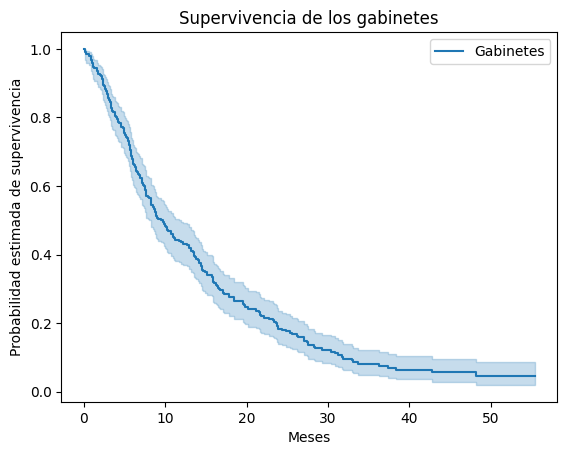

Probabilidad estimada de supervivencia después de 20 meses: 0.25


In [4]:
!pip install lifelines --quiet

import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter

km = KaplanMeierFitter()

km.fit(
    durations=eha["duracion_meses"],
    event_observed=eha["caida_evento"],
    label="Gabinetes"
)

km.plot_survival_function()

plt.xlabel("Meses")
plt.ylabel("Probabilidad estimada de supervivencia")
plt.title("Supervivencia de los gabinetes")
plt.show()

tiempo = 20  # elija el número de meses

supervivencia = km.predict(tiempo)

print(
    f"Probabilidad estimada de supervivencia después de {tiempo} meses:",
    round(supervivencia, 2)
)


### Cómo leer la curva

Comenzamos cerca de 1 porque, al inicio, todos los gabinetes están en funciones.

La curva desciende cuando observamos caídas.

En cualquier momento podemos preguntar:

> ¿Qué proporción estimada de gabinetes continúa en funciones más allá de este tiempo?

El bloque también calcula la supervivencia estimada a los **20 meses**. Lea el valor reportado por Python como una afirmación concreta:

> Pasados 20 meses, la probabilidad estimada de que un gabinete continúe en funciones es aproximadamente el valor reportado.


## EHA-04 — Comparar gobiernos mayoritarios y minoritarios

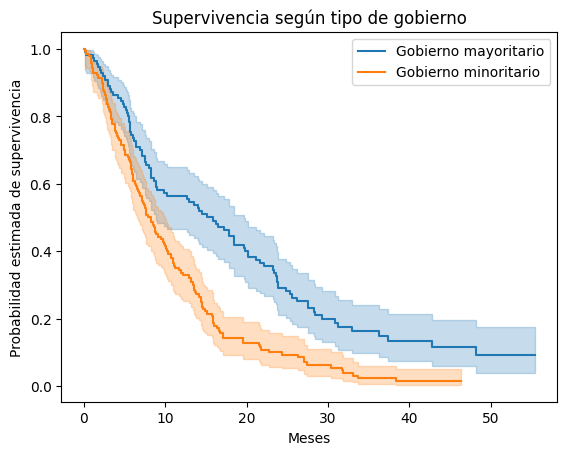

In [5]:
ax = plt.subplot(111)

mayoria = (eha["gobierno_mayoritario"] == 1)

km.fit(
    eha.loc[mayoria, "duracion_meses"],
    event_observed=eha.loc[mayoria, "caida_evento"],
    label="Gobierno mayoritario"
)
km.plot_survival_function(ax=ax)

km.fit(
    eha.loc[~mayoria, "duracion_meses"],
    event_observed=eha.loc[~mayoria, "caida_evento"],
    label="Gobierno minoritario"
)
km.plot_survival_function(ax=ax)

plt.xlabel("Meses")
plt.ylabel("Probabilidad estimada de supervivencia")
plt.title("Supervivencia según tipo de gobierno")
plt.show()


### Qué comparar

Si una curva permanece por encima de la otra, ese grupo muestra mayor supervivencia durante esa parte del período observado.

Primero miramos el patrón. Después evaluamos si la diferencia es suficientemente sistemática.

## EHA-05 — Evaluar la diferencia entre las curvas

In [6]:
from lifelines.statistics import logrank_test

logrank = logrank_test(
    eha.loc[mayoria, "duracion_meses"],
    eha.loc[~mayoria, "duracion_meses"],
    event_observed_A=eha.loc[mayoria, "caida_evento"],
    event_observed_B=eha.loc[~mayoria, "caida_evento"]
)

print("p-valor Log-Rank:", round(logrank.p_value, 4))

p-valor Log-Rank: 0.0


### Cómo leerlo

El Log-Rank pregunta si la experiencia de supervivencia de ambos grupos puede considerarse igual a lo largo del tiempo.

El p-valor no nos dice **cuánto** difieren políticamente. Para eso seguimos mirando las curvas y luego modelamos el riesgo.

## EHA-06 — Modelar el riesgo de caída

In [7]:
from lifelines import CoxPHFitter

eha_cox = eha[
    [
        "duracion_meses",
        "caida_evento",
        "gobierno_mayoritario",
        "fragmentacion",
        "crecimiento_pbi"
    ]
].copy()

cox = CoxPHFitter()
cox.fit(
    eha_cox,
    duration_col="duracion_meses",
    event_col="caida_evento"
)


<lifelines.CoxPHFitter: fitted with 250 total observations, 19 right-censored observations>

### Qué pasó?

Si el bloque se ejecutó sin errores, el modelo de Cox ya fue estimado.

El resultado está almacenado en `cox`.

En el siguiente bloque extraeremos los **Hazard Ratios (HR)** y sus p-valores para aprender a interpretarlos.

## EHA-07 — Extraer los Hazard Ratios

In [8]:
resultado_hr = pd.DataFrame({
    "HR": cox.hazard_ratios_,
    "p_valor": cox.summary["p"]
}).round(3)

resultado_hr

,HR,p_valor
covariate,,
gobierno_mayoritario,0.477,0.0
fragmentacion,1.252,0.0
crecimiento_pbi,0.892,0.0


### Cómo leer los Hazard Ratios

- `HR = 1`: el riesgo se multiplica por 1.
- `HR > 1`: el riesgo se multiplica por un factor mayor que 1.
- `HR < 1`: el riesgo se multiplica por un factor menor que 1.

Para `gobierno_mayoritario`, un HR de aproximadamente 0.48 indica que ser un gobierno mayoritario **multiplica el riesgo instantáneo de caída por 0.48**, manteniendo constantes las demás variables.

Para `fragmentacion`, un HR de aproximadamente 1.25 indica que cada unidad adicional de fragmentación **multiplica el riesgo instantáneo de caída por 1.25**.

Para `crecimiento_pbi`, un HR de aproximadamente 0.89 indica que cada unidad adicional de crecimiento **multiplica el riesgo instantáneo de caída por 0.89**.


## EHA-08 — Comprobar el supuesto de riesgos proporcionales

In [9]:
cox.check_assumptions(
    eha_cox,
    p_value_threshold=0.05,
    show_plots=False
)

Proportional hazard assumption looks okay.


[]

### Por qué hacemos este diagnóstico

El modelo de Cox supone que la relación entre los riesgos permanece proporcional a lo largo del tiempo.

No necesitamos memorizar el procedimiento de diagnóstico. Necesitamos saber qué pregunta responde:

> ¿Es razonable utilizar un único Hazard Ratio para resumir la relación durante todo el período observado?

Si el diagnóstico señala problemas, debemos revisar esa interpretación.